In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [80]:
RED_DARK = '#cc6971'
RED = '#ff929b'
RED_LIGHT = '#ffacb3'

ORANGE_DARK = '#e09458'
ORANGE = '#ffb982'
ORANGE_LIGHT = '#ffcfa9'

YELLOW_DARK = '#cca256'
YELLOW = '#ffcb6b'
YELLOW_LIGHT = '#ffdb99'

GREEN_DARK = '#98b56e'
GREEN = '#c3e88d'
GREEN_LIGHT = '#dbffa5'

CYAN_DARK = '#7db9b5'
CYAN = '#9fece7'
CYAN_LIGHT = '#c5fffb'

BLUE_DARK = '#62a2cc'
BLUE = '#7bcbff'
BLUE_LIGHT = '#9cd8ff'

MAGENTA_DARK = '#b28ecc'
MAGENTA = '#deb2ff'
MAGENTA_LIGHT = '#e9cbff'

In [81]:
def load_simulation_results(bw, sf, cr, preamble_len, tx_delta):
    sim_results = {
        'shift_ms': [],
        'failures_tx1': [],
        'failures_tx2': [],
    }

    seen_offsets = set()

    for file in os.listdir('./data'):
        settings = f'bw{bw}_sf{sf}_cr{cr}_pre{preamble_len}_txd{tx_delta}_'
        if file.endswith('.csv') and file.startswith(settings):
            file_path = os.path.join('./data', file)
            offset = int(file.split(f'txd{tx_delta}_')[1].split('.csv')[0].split('_')[0])
            if offset in seen_offsets:
                continue
            seen_offsets.add(offset)

            receiver_packets = file_path.replace('_phy_packets.csv', '_receiver_packets.csv')
            phy_packets = file_path.replace('_receiver_packets.csv', '_phy_packets.csv')

            receiver_df = pd.read_csv(receiver_packets)
            phy_df = pd.read_csv(phy_packets)

            receiver_df.set_index('id', inplace=True)
            phy_df.set_index('id', inplace=True)

            receiver_df['radio_id'] = phy_df['radio_id']

            rx1 = receiver_df[receiver_df['radio_id'] == 1]
            rx1_total = len(rx1['collision'])
            rx1_collisions = len(rx1[rx1['collision'] == True])

            rx2 = receiver_df[receiver_df['radio_id'] == 2]
            rx2_total = len(rx2['collision'])
            rx2_collisions = len(rx2[rx2['collision'] == True])

            sim_results['shift_ms'].append(offset)
            sim_results['failures_tx1'].append((rx1_collisions / rx1_total) * 100)
            sim_results['failures_tx2'].append((rx2_collisions / rx2_total) * 100)

    df = pd.DataFrame(sim_results)
    df.sort_values('shift_ms', inplace=True)
    df.reset_index(inplace=True, drop=True)
    df['shift_s'] = df['shift_ms'] / 1000
    return df

In [82]:
# See page 8 of the paper "LoRa Scalability A Simulation Model Based on interference measurements"
table_2 = pd.DataFrame({
    'shift_ms': [
        100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600
    ],
    'collisions_tx1': [
        2.2, 4, 3.2, 3, 4.4, 2, 3.4, 2.4, 0.8, 0.8, 2, 2, 1, 2.2, 1, 2
    ],
    'collisions_tx2': [
        100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 84, 24, 5.2
    ],
    'bad_crc_tx1': [
        25, 9, 4.4, 1, 7, 4.3, 3.5, 8.4, 4.3, 2.5, 5.4, 3.2, 2.1, 0, 2.1, 4.5
    ],
    'bad_crc_tx2': [
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0
    ],
})

table_2['shift_s'] = table_2['shift_ms'] / 1000
table_2['failures_tx1'] = table_2['collisions_tx1'] + table_2['bad_crc_tx1']
table_2['failures_tx2'] = table_2['collisions_tx2'] + table_2['bad_crc_tx2']

table_2

,shift_ms,collisions_tx1,collisions_tx2,bad_crc_tx1,bad_crc_tx2,shift_s,failures_tx1,failures_tx2
0,100,2.2,100.0,25.0,0,0.1,27.2,100.0
1,200,4.0,100.0,9.0,0,0.2,13.0,100.0
2,300,3.2,100.0,4.4,0,0.3,7.6,100.0
3,400,3.0,100.0,1.0,0,0.4,4.0,100.0
4,500,4.4,100.0,7.0,0,0.5,11.4,100.0
5,600,2.0,100.0,4.3,0,0.6,6.3,100.0
6,700,3.4,100.0,3.5,0,0.7,6.9,100.0
7,800,2.4,100.0,8.4,0,0.8,10.8,100.0
8,900,0.8,100.0,4.3,0,0.9,5.1,100.0
9,1000,0.8,100.0,2.5,0,1.0,3.3,100.0


In [83]:
# Table 2 uses the following settings
table_2_sim = load_simulation_results(bw=125, sf=12, cr=8, preamble_len=8, tx_delta=0)
table_2_sim

,shift_ms,failures_tx1,failures_tx2,shift_s
0,100,100.000000,100.000000,0.10
1,200,4.750000,100.000000,0.20
2,300,5.083333,100.000000,0.30
3,400,5.083333,100.000000,0.40
4,500,5.333333,100.000000,0.50
5,600,5.500000,100.000000,0.60
6,700,4.833333,100.000000,0.70
7,800,4.416667,100.000000,0.80
8,900,5.083333,100.000000,0.90
9,1000,5.416667,100.000000,1.00


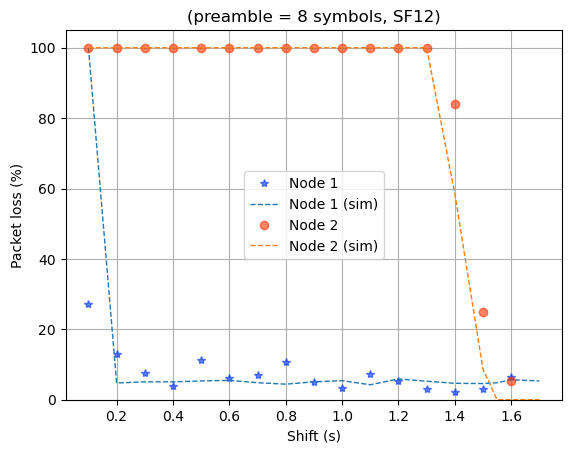

In [84]:
fig, ax = plt.subplots(1,1)

ax.plot(table_2['shift_s'], table_2['failures_tx1'], '*', label='Node 1', color=(0, 0.2, 1, 0.6))
ax.plot(table_2_sim['shift_s'], table_2_sim['failures_tx1'], label='Node 1 (sim)', linewidth=1, linestyle='dashed')

ax.plot(table_2['shift_s'], table_2['failures_tx2'], 'o', label='Node 2', color=(1, 0.2, 0, 0.6))
ax.plot(table_2_sim['shift_s'], table_2_sim['failures_tx2'], label='Node 2 (sim)', linewidth=1, linestyle='dashed')

ax.set_xlabel('Shift (s)')
ax.grid()

ax.set_ylabel('Packet loss (%)')
ax.set_ylim(0, 105)

# preamble = 401.41 / 1000
# ax.vlines(preamble, 0, 105, colors='purple', linestyles='dotted', label='Preamble end')

ax.set_title('(preamble = 8 symbols, SF12)')
ax.legend()

In [85]:
# See page 8 of the paper "LoRa Scalability A Simulation Model Based on interference measurements"
table_3 = pd.DataFrame({
    'shift_ms': [
        5, 10, 20, 30, 40, 50, 60, 70,
    ],
    'collisions_tx1': [
        2.3, 2.1, 2.8, 2.5, 2.1, 2, 0, 0
    ],
    'collisions_tx2': [
        100, 100, 100, 100, 100, 100, 100, 0
    ],
    'bad_crc_tx1': [
        18, 7, 4, 5.2, 3.1, 2.1, 2, 0,
    ],
    'bad_crc_tx2': [
        0, 0, 0, 0, 0, 0, 0, 0
    ],
})

table_3['shift_s'] = table_3['shift_ms'] / 1000
table_3['failures_tx1'] = table_3['collisions_tx1'] + table_3['bad_crc_tx1']
table_3['failures_tx2'] = table_3['collisions_tx2'] + table_3['bad_crc_tx2']

table_3

,shift_ms,collisions_tx1,collisions_tx2,bad_crc_tx1,bad_crc_tx2,shift_s,failures_tx1,failures_tx2
0,5,2.3,100,18.0,0,0.005,20.3,100
1,10,2.1,100,7.0,0,0.010,9.1,100
2,20,2.8,100,4.0,0,0.020,6.8,100
3,30,2.5,100,5.2,0,0.030,7.7,100
4,40,2.1,100,3.1,0,0.040,5.2,100
5,50,2.0,100,2.1,0,0.050,4.1,100
6,60,0.0,100,2.0,0,0.060,2.0,100
7,70,0.0,0,0.0,0,0.070,0.0,0


In [86]:
# Table 3 uses the following settings
table_3_sim = load_simulation_results(bw=125, sf=7, cr=8, preamble_len=14, tx_delta=0)
table_3_sim

,shift_ms,failures_tx1,failures_tx2,shift_s
0,5,100.000000,100.0,0.005
1,10,6.083333,100.0,0.010
2,20,4.083333,100.0,0.020
3,30,4.916667,100.0,0.030
4,40,6.833333,100.0,0.040
5,50,5.000000,100.0,0.050
6,60,4.166667,100.0,0.060
7,70,4.333333,0.0,0.070
8,80,0.000000,0.0,0.080


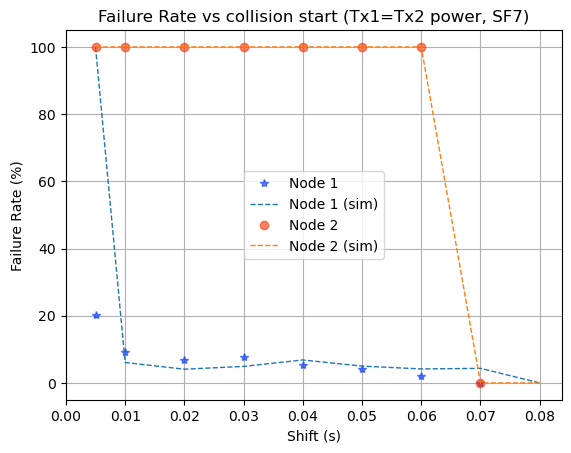

In [87]:
fig, ax = plt.subplots(1,1)

ax.set_xlabel('Shift (s)')
ax.grid()

ax.plot(table_3['shift_s'], table_3['failures_tx1'], '*', label='Node 1', color=(0, 0.2, 1, 0.6))
ax.plot(table_3_sim['shift_s'], table_3_sim['failures_tx1'], label='Node 1 (sim)', linewidth=1, linestyle='dashed')

ax.plot(table_3['shift_s'], table_3['failures_tx2'], 'o', label='Node 2', color=(1, 0.2, 0, 0.6))
ax.plot(table_3_sim['shift_s'], table_3_sim['failures_tx2'], label='Node 2 (sim)', linewidth=1, linestyle='dashed')

ax.set_ylabel('Failure Rate (%)')
ax.set_ylim(-5, 105)

ax.set_xlim(0)

# preamble = 18.69 / 1000
# ax.vlines(preamble, 0, 105, colors='red', linestyles='dashed', label='Preamble end')

ax.set_title('Failure Rate vs collision start (Tx1=Tx2 power, SF7)')
ax.legend()

In [88]:
# See page 10 of the paper "LoRa Scalability A Simulation Model Based on interference measurements"
table_4 = pd.DataFrame({
    'shift_ms': [
        100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600
    ],
    'collisions_tx1': [
        100, 100, 100, 100, 62, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
    ],
    'collisions_tx2': [
        100, 100, 100, 0, 50, 100, 100, 100, 100, 100, 100, 100, 100, 48, 0, 0
    ],
    'bad_crc_tx1': [
        0, 0, 0, 0, 38, 98, 100, 100, 100, 100, 100, 100, 100, 99, 73, 1
    ],
    'bad_crc_tx2': [
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0
    ],
})

table_4['shift_s'] = table_4['shift_ms'] / 1000
table_4['failures_tx1'] = table_4['collisions_tx1'] + table_4['bad_crc_tx1']
table_4['failures_tx2'] = table_4['collisions_tx2'] + table_4['bad_crc_tx2']

table_4

,shift_ms,collisions_tx1,collisions_tx2,bad_crc_tx1,bad_crc_tx2,shift_s,failures_tx1,failures_tx2
0,100,100,100,0,0,0.1,100,100
1,200,100,100,0,0,0.2,100,100
2,300,100,100,0,0,0.3,100,100
3,400,100,0,0,0,0.4,100,0
4,500,62,50,38,0,0.5,100,50
5,600,2,100,98,0,0.6,100,100
6,700,0,100,100,0,0.7,100,100
7,800,0,100,100,0,0.8,100,100
8,900,0,100,100,0,0.9,100,100
9,1000,0,100,100,0,1.0,100,100


In [89]:
# Table 4 was recorded using the following settings
table_4_sim = load_simulation_results(bw=125, sf=12, cr=8, preamble_len=8, tx_delta=12)
table_4_sim

,shift_ms,failures_tx1,failures_tx2,shift_s
0,100,100.0,100.000000,0.10
1,200,100.0,100.000000,0.20
2,300,100.0,85.666667,0.30
3,400,100.0,33.083333,0.40
4,500,100.0,0.000000,0.50
5,600,100.0,0.000000,0.60
6,700,100.0,100.000000,0.70
7,800,100.0,100.000000,0.80
8,900,100.0,100.000000,0.90
9,1000,100.0,100.000000,1.00


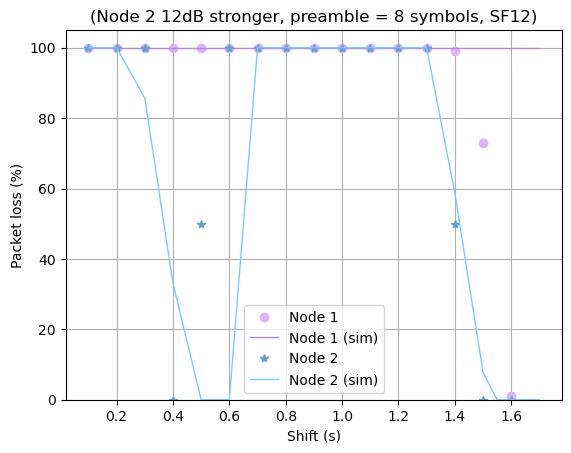

In [97]:
fig, ax = plt.subplots(1,1)

ax.set_xlabel('Shift (s)')
ax.grid()

ax.plot(table_4['shift_s'], table_4['failures_tx1'], 'o', label='Node 1', color=MAGENTA)
ax.plot(table_4_sim['shift_s'], table_4_sim['failures_tx1'], label='Node 1 (sim)', color=MAGENTA_DARK, linewidth=1)

ax.plot(table_4['shift_s'], table_4['failures_tx2'], '*', label='Node 2', color=BLUE_DARK)
ax.plot(table_4_sim['shift_s'], table_4_sim['failures_tx2'], label='Node 2 (sim)', color=BLUE, linewidth=1)

# preamble = 401.41 / 1000
# ax.vlines(preamble, 0, 105, linestyles='dashed', label='Preamble end')

ax.set_ylabel('Packet loss (%)')
ax.set_ylim(0, 105)

ax.set_title('(Node 2 12dB stronger, preamble = 8 symbols, SF12)')
ax.legend()

In [91]:
# See page 8 of the paper "LoRa Scalability A Simulation Model Based on interference measurements"
table_5 = pd.DataFrame({
    'shift_ms': [
        5, 10, 20, 30, 40, 50, 60, 70,
    ],
    'collisions_tx1': [
        100, 100, 72, 0, 0, 0, 0, 0
    ],
    'collisions_tx2': [
        100, 100, 41, 100, 100, 100, 100, 0
    ],
    'bad_crc_tx1': [
        0, 0, 28, 100, 100, 100, 100, 0
    ],
    'bad_crc_tx2': [
        0, 0, 0, 0, 0, 0, 0, 0,
    ],
})

table_5['shift_s'] = table_5['shift_ms'] / 1000
table_5['failures_tx1'] = table_5['collisions_tx1'] + table_5['bad_crc_tx1']
table_5['failures_tx2'] = table_5['collisions_tx2'] + table_5['bad_crc_tx2']

table_5

,shift_ms,collisions_tx1,collisions_tx2,bad_crc_tx1,bad_crc_tx2,shift_s,failures_tx1,failures_tx2
0,5,100,100,0,0,0.005,100,100
1,10,100,100,0,0,0.010,100,100
2,20,72,41,28,0,0.020,100,41
3,30,0,100,100,0,0.030,100,100
4,40,0,100,100,0,0.040,100,100
5,50,0,100,100,0,0.050,100,100
6,60,0,100,100,0,0.060,100,100
7,70,0,0,0,0,0.070,0,0


In [92]:
# Table 5 was recorded using the following settings
table_5_sim = load_simulation_results(bw=125, sf=7, cr=8, preamble_len=14, tx_delta=12)
table_5_sim

,shift_ms,failures_tx1,failures_tx2,shift_s
0,5,100.0,100.0,0.005
1,8,100.0,100.0,0.008
2,10,100.0,100.0,0.010
3,15,100.0,79.5,0.015
4,20,100.0,0.0,0.020
5,30,100.0,100.0,0.030
6,40,100.0,100.0,0.040
7,50,100.0,100.0,0.050
8,60,100.0,100.0,0.060
9,70,100.0,0.0,0.070


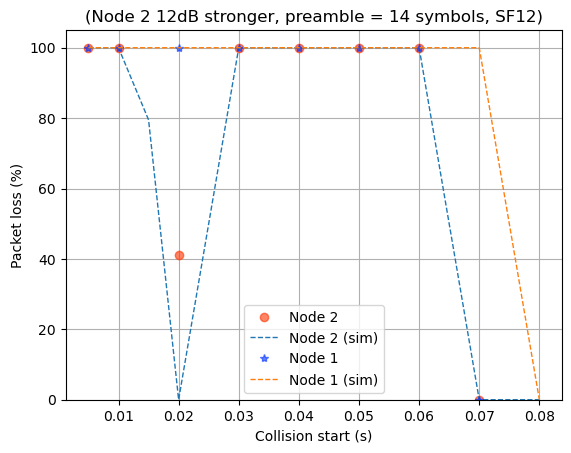

In [93]:
fig, ax = plt.subplots(1,1)

ax.set_xlabel('Collision start (s)')
ax.grid()

ax.plot(table_5['shift_s'], table_5['failures_tx2'], 'o', label='Node 2', color=(1, 0.2, 0, 0.6))
ax.plot(table_5_sim['shift_s'], table_5_sim['failures_tx2'], label='Node 2 (sim)', linewidth=1, linestyle='dashed')

ax.plot(table_5['shift_s'], table_5['failures_tx1'], '*', label='Node 1', color=(0, 0.2, 1, 0.6))
ax.plot(table_5_sim['shift_s'], table_5_sim['failures_tx1'], label='Node 1 (sim)', linewidth=1, linestyle='dashed')

# preamble = 18.69 / 1000
# ax.vlines(preamble, 0, 105, colors='red', linestyles='dashed', label='Preamble end')

ax.set_ylabel('Packet loss (%)')
ax.set_ylim(0, 105)

ax.set_title('(Node 2 12dB stronger, preamble = 14 symbols, SF12)')
ax.legend()